<a href="https://colab.research.google.com/github/cramosh-droid/streamlit-m5/blob/main/RetoEmpleados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

datos = ('/content/drive/MyDrive/Colab Notebooks/datos/empleadosreto.csv')
empleados_attrition = pd.read_csv(datos)
empleados_attrition.info(max_cols=len(empleados_attrition.columns), show_counts=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       400 non-null    int64 
 1   BusinessTravel            396 non-null    object
 2   Department                400 non-null    object
 3   DistanceFromHome          400 non-null    object
 4   Education                 400 non-null    int64 
 5   EducationField            400 non-null    object
 6   EmployeeCount             400 non-null    int64 
 7   EmployeeNumber            400 non-null    int64 
 8   EnvironmentSatisfaction   400 non-null    int64 
 9   Gender                    400 non-null    object
 10  JobInvolvement            400 non-null    int64 
 11  JobLevel                  400 non-null    int64 
 12  JobRo

In [2]:
empleados_attrition_limpio = empleados_attrition.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'])
empleados_attrition_limpio.info(max_cols=len(empleados_attrition_limpio.columns), show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       400 non-null    int64 
 1   BusinessTravel            396 non-null    object
 2   Department                400 non-null    object
 3   DistanceFromHome          400 non-null    object
 4   Education                 400 non-null    int64 
 5   EducationField            400 non-null    object
 6   EnvironmentSatisfaction   400 non-null    int64 
 7   Gender                    400 non-null    object
 8   JobInvolvement            400 non-null    int64 
 9   JobLevel                  400 non-null    int64 
 10  JobRole                   400 non-null    object
 11  JobSatisfaction           400 non-null    int64 
 12  MaritalStatus             395 non-null    object
 13  MonthlyIncome             400 non-null    int64 
 14  NumCompaniesWorked        

In [3]:
empleados_attrition_limpio['HiringDate']=pd.to_datetime(empleados_attrition_limpio['HiringDate'], format='%m/%d/%Y', errors='coerce')
empleados_attrition_limpio['Year']=empleados_attrition_limpio['HiringDate'].dt.year.astype('Int64')
actual = 2018
empleados_attrition_limpio['YearsAtCompany']= actual - empleados_attrition_limpio['Year']
#empleados_attrition_limpio.info(max_cols=len(empleados_attrition_limpio.columns),show_counts=True)
empleados_attrition_limpio['YearsAtCompany'].head()

,YearsAtCompany
0,5
1,3
2,1
3,8
4,7


In [4]:
# 1. Creamos la columna con el texto original '_km' haciendo una copia independiente
empleados_attrition_limpio['DistanceFromHome_km'] = empleados_attrition_limpio['DistanceFromHome'].copy()

# 2. Ahora limpiamos SOLO la columna 'DistanceFromHome' para que sea puramente entera
# Tu columna 'DistanceFromHome_km' se mantendrá intacta con su " km" al final
empleados_attrition_limpio['DistanceFromHome'] = (
    empleados_attrition_limpio['DistanceFromHome']
    .astype(str)
    .str.replace(' km', '', regex=False)
    .astype('Int64')
)
print(empleados_attrition_limpio[['DistanceFromHome_km', 'DistanceFromHome']].head())
empleados_attrition_limpio.info(max_cols=len(empleados_attrition_limpio.columns), show_counts=True)

  DistanceFromHome_km  DistanceFromHome
0                1 km                 1
1                6 km                 6
2                7 km                 7
3                7 km                 7
4               15 km                15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Age                       400 non-null    int64         
 1   BusinessTravel            396 non-null    object        
 2   Department                400 non-null    object        
 3   DistanceFromHome          400 non-null    Int64         
 4   Education                 400 non-null    int64         
 5   EducationField            400 non-null    object        
 6   EnvironmentSatisfaction   400 non-null    int64         
 7   Gender                    400 non-null    object        
 8   JobInvolvement            400 

In [5]:
empleados_attrition_limpio = empleados_attrition_limpio.drop(['HiringDate', 'Year', 'DistanceFromHome_km'], axis=1, errors='ignore')
empleados_attrition_limpio.info(max_cols=len(empleados_attrition_limpio.columns), show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       400 non-null    int64 
 1   BusinessTravel            396 non-null    object
 2   Department                400 non-null    object
 3   DistanceFromHome          400 non-null    Int64 
 4   Education                 400 non-null    int64 
 5   EducationField            400 non-null    object
 6   EnvironmentSatisfaction   400 non-null    int64 
 7   Gender                    400 non-null    object
 8   JobInvolvement            400 non-null    int64 
 9   JobLevel                  400 non-null    int64 
 10  JobRole                   400 non-null    object
 11  JobSatisfaction           400 non-null    int64 
 12  MaritalStatus             395 non-null    object
 13  MonthlyIncome             400 non-null    int64 
 14  NumCompaniesWorked        

In [6]:
SueldoPromedioDepto = empleados_attrition_limpio.groupby('Department')['MonthlyIncome'].mean().reset_index()
SueldoPromedio = SueldoPromedioDepto
print(SueldoPromedio)

               Department  MonthlyIncome
0         Human Resources    6239.888889
1  Research & Development    6804.149813
2                   Sales    7188.250000


In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
empleados_attrition_limpio['MonthlyIncome'] = scaler.fit_transform(empleados_attrition_limpio[['MonthlyIncome']])
print(empleados_attrition_limpio['MonthlyIncome'].head())

0    0.864269
1    0.207340
2    0.088062
3    0.497574
4    0.664470
Name: MonthlyIncome, dtype: float64


In [8]:
if empleados_attrition_limpio['Attrition'].dtype == 'object':
    empleados_attrition_limpio['Attrition'] = empleados_attrition_limpio['Attrition'].map({'Yes': 1, 'No': 0})


columnas_categoricas = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


empleados_attrition_limpio = pd.get_dummies(
    empleados_attrition_limpio,
    columns=columnas_categoricas,
    drop_first=False
)


columnas_nuevas = [col for col in empleados_attrition_limpio.columns if col != 'Attrition']
for col in empleados_attrition_limpio.columns:
    if empleados_attrition_limpio[col].dtype == 'bool':
        empleados_attrition_limpio[col] = empleados_attrition_limpio[col].astype(int)


empleados_attrition_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                400 non-null    int64  
 1   DistanceFromHome                   400 non-null    Int64  
 2   Education                          400 non-null    int64  
 3   EnvironmentSatisfaction            400 non-null    int64  
 4   JobInvolvement                     400 non-null    int64  
 5   JobLevel                           400 non-null    int64  
 6   JobSatisfaction                    400 non-null    int64  
 7   MonthlyIncome                      400 non-null    float64
 8   NumCompaniesWorked                 400 non-null    int64  
 9   OverTime                           400 non-null    object 
 10  PercentSalaryHike                  400 non-null    int64  
 11  PerformanceRating                  400 non-null    int64  

In [9]:
print(empleados_attrition_limpio[['Attrition']].head())

   Attrition
0          0
1          0
2          1
3          0
4          1


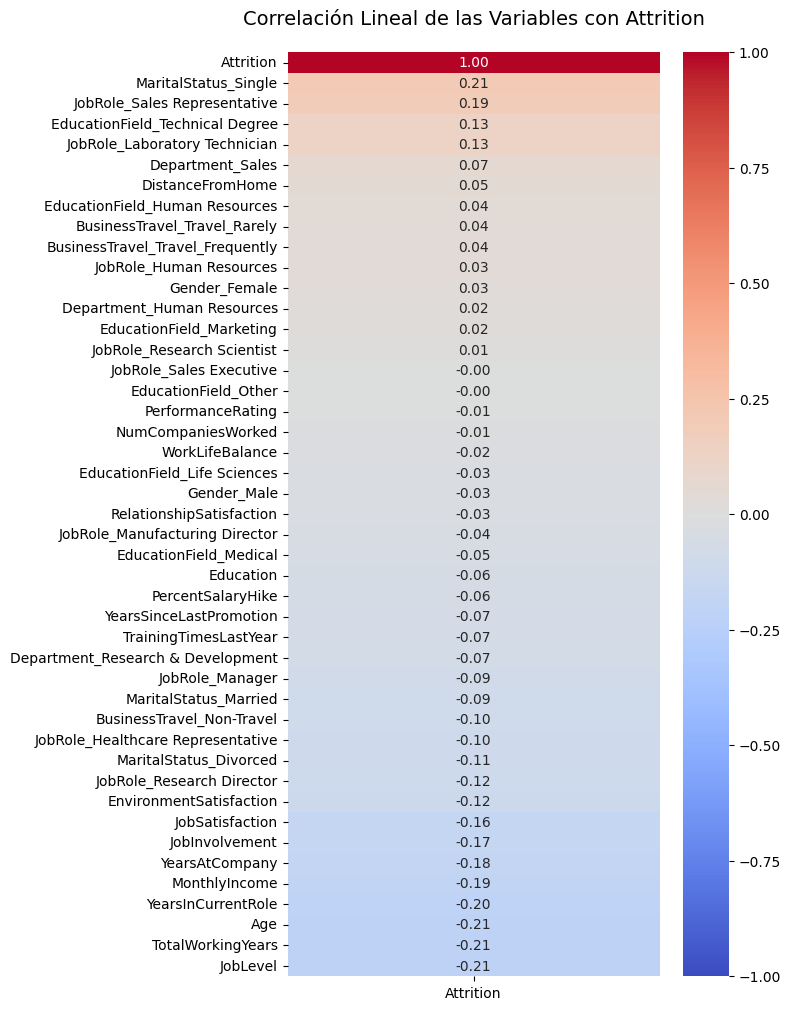

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
correlacion = empleados_attrition_limpio.corr(numeric_only=True)[['Attrition']].sort_values(by='Attrition', ascending=False)
plt.figure(figsize=(6, 12))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Correlación Lineal de las Variables con Attrition', fontsize=14, pad=20)
plt.show()

In [11]:
columnas_seleccionadas = [
    'Attrition',
    'JobRole_Laboratory Technician',
    'EducationField_Technical Degree',
    'JobRole_Sales Representative',
    'MaritalStatus_Single',
    'BusinessTravel_Non-Travel',
    'JobRole_Healthcare Representative',
    'MaritalStatus_Divorced',
    'JobRole_Research Director',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'JobInvolvement',
    'YearsAtCompany',
    'MonthlyIncome',
    'YearsInCurrentRole',
    'Age',
    'TotalWorkingYears',
    'JobLevel'
]

EmpleadosAttritionFinal = empleados_attrition_limpio[columnas_seleccionadas].copy()

EmpleadosAttritionFinal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Attrition                          400 non-null    int64  
 1   JobRole_Laboratory Technician      400 non-null    int64  
 2   EducationField_Technical Degree    400 non-null    int64  
 3   JobRole_Sales Representative       400 non-null    int64  
 4   MaritalStatus_Single               400 non-null    int64  
 5   BusinessTravel_Non-Travel          400 non-null    int64  
 6   JobRole_Healthcare Representative  400 non-null    int64  
 7   MaritalStatus_Divorced             400 non-null    int64  
 8   JobRole_Research Director          400 non-null    int64  
 9   EnvironmentSatisfaction            400 non-null    int64  
 10  JobSatisfaction                    400 non-null    int64  
 11  JobInvolvement                     400 non-null    int64  

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = EmpleadosAttritionFinal.drop(columns=['Attrition'])

# Impute missing values in 'YearsAtCompany' with the median
X['YearsAtCompany'].fillna(X['YearsAtCompany'].median(), inplace=True)

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)
pca = PCA(n_components=2)
EmpleadosAttritionPCA = pca.fit_transform(X_escalado)
print("Tipo de variable:", type(EmpleadosAttritionPCA))
print("Dimensiones del array:", EmpleadosAttritionPCA.shape)

Tipo de variable: <class 'numpy.ndarray'>
Dimensiones del array: (400, 2)


/tmp/ipykernel_11093/723189302.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['YearsAtCompany'].fillna(X['YearsAtCompany'].median(), inplace=True)


In [14]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


pca_analisis = PCA()
pca_analisis.fit(X_escalado)

varianza_acumulada = np.cumsum(pca_analisis.explained_variance_ratio_)

n_componentes_80 = np.argmax(varianza_acumulada >= 0.80) + 1
print(f"Número mínimo de componentes para el 80% de varianza: {n_componentes_80}")

pca = PCA(n_components=n_componentes_80)
EmpleadosAttritionPCA = pca.fit_transform(X_escalado)

nuevas_columnas = {}

for i in range(n_componentes_80):
    nuevas_columnas[f'C{i}'] = EmpleadosAttritionPCA[:, i]

EmpleadosAttritionFinal = EmpleadosAttritionFinal.assign(**nuevas_columnas)

print("\nColumnas actuales en EmpleadosAttritionFinal:")
print(EmpleadosAttritionFinal.columns.tolist())

Número mínimo de componentes para el 80% de varianza: 10

Columnas actuales en EmpleadosAttritionFinal:
['Attrition', 'JobRole_Laboratory Technician', 'EducationField_Technical Degree', 'JobRole_Sales Representative', 'MaritalStatus_Single', 'BusinessTravel_Non-Travel', 'JobRole_Healthcare Representative', 'MaritalStatus_Divorced', 'JobRole_Research Director', 'EnvironmentSatisfaction', 'JobSatisfaction', 'JobInvolvement', 'YearsAtCompany', 'MonthlyIncome', 'YearsInCurrentRole', 'Age', 'TotalWorkingYears', 'JobLevel', 'C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']


In [15]:
columnas_ordenadas = [col for col in EmpleadosAttritionFinal.columns if col != 'Attrition']
columnas_ordenadas.append('Attrition')

EmpleadosAttritionFinal = EmpleadosAttritionFinal[columnas_ordenadas]
EmpleadosAttritionFinal.to_csv('EmpleadosAttritionFinal.csv', index=False)

print("¡Archivo 'EmpleadosAttritionFinal.csv' guardado con éxito!")

¡Archivo 'EmpleadosAttritionFinal.csv' guardado con éxito!
